# Sprint - 2 Probability

# 05_Probability

### What is Probability?

Probability is the branch of mathematics that measures how likely an event is to occur, expressed as a number between 0 (impossible) and 1 (certain). It gives us a formal language to reason about uncertainty — from predicting weather and diagnosing diseases to filtering spam and powering recommendation engines. Probability theory is the foundation of statistics and machine learning, since almost every model (classification, regression, generative AI) ultimately reasons in terms of likelihoods and distributions.

## 01. Introduction to Probability

**Definition**: Probability quantifies the chance of an event occurring, calculated as the ratio of favorable outcomes to total possible outcomes, always between 0 and 1.

**Formula**: P(A) = Number of favorable outcomes / Total number of outcomes

**Real-World Example**: The probability of a fair coin landing heads is 0.5.

**Business Example**: The probability that a website visitor completes a purchase (conversion rate).

**AI/ML Example**: Classification models (e.g., logistic regression) output a probability score for each class rather than a hard label.

**Numerical Example**: Rolling a fair six-sided die, P(rolling a 4) = 1/6 ≈ 0.1667.

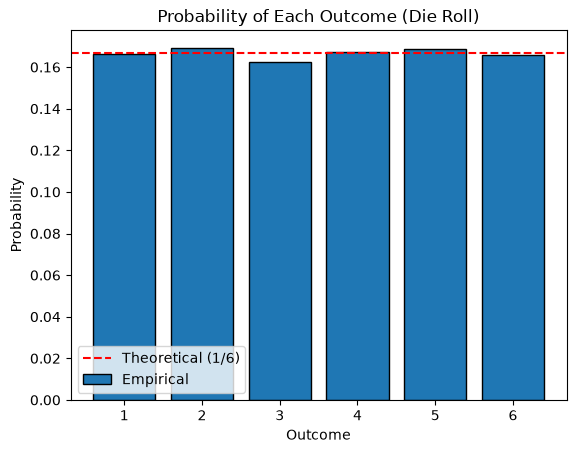

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
rolls = np.random.randint(1, 7, size=10000)

values, counts = np.unique(rolls, return_counts=True)
empirical_probs = counts / len(rolls)

plt.bar(values, empirical_probs, edgecolor="black", label="Empirical")
plt.axhline(1/6, color="red", linestyle="--", label="Theoretical (1/6)")
plt.title("Probability of Each Outcome (Die Roll)")
plt.xlabel("Outcome")
plt.ylabel("Probability")
plt.legend()
plt.show()

### Interpretation:
Each face of the die appears close to 1/6 of the time (~16.7%) as the number of trials grows, illustrating the Law of Large Numbers converging toward the theoretical probability.

### Advantages:
- Provides a rigorous, universal framework to quantify uncertainty.
- Forms the mathematical backbone of statistics, ML, and decision-making.

### Limitations:
- Requires well-defined outcomes and assumptions (e.g., fairness) that may not hold in reality.
- Small sample sizes can produce empirical probabilities that deviate noticeably from theoretical ones.

## 02. Events

**Definition**: An event is a subset of the sample space — one outcome (simple event) or a combination of outcomes (compound event) from a random experiment.

**Formula**: P(Event) = n(E) / n(S), where n(E) is the number of outcomes in the event and n(S) is the total number of outcomes in the sample space.

**Real-World Example**: Drawing a red card from a standard deck of 52 playing cards.

**Business Example**: The event "a customer completes a purchase within 7 days of signing up."

**AI/ML Example**: In binary classification, "model predicts spam" is an event whose probability the model estimates.

**Numerical Example**: Rolling two dice, the event "sum equals 7" has 6 favorable outcomes out of 36, so P = 6/36 ≈ 0.167.

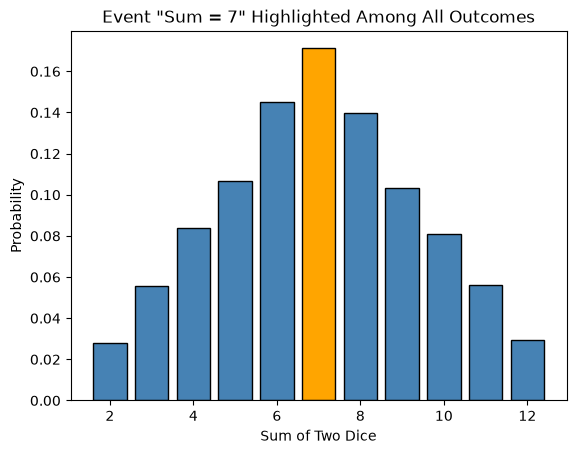

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)
die1 = np.random.randint(1, 7, size=10000)
die2 = np.random.randint(1, 7, size=10000)
sums = die1 + die2

values, counts = np.unique(sums, return_counts=True)
probs = counts / len(sums)

colors = ["orange" if v == 7 else "steelblue" for v in values]
plt.bar(values, probs, color=colors, edgecolor="black")
plt.title('Event "Sum = 7" Highlighted Among All Outcomes')
plt.xlabel("Sum of Two Dice")
plt.ylabel("Probability")
plt.show()

### Interpretation:
The highlighted bar (sum = 7) is the tallest, confirming it's the most likely compound event when rolling two dice — matching the theoretical probability of 6/36.

### Advantages:
- Breaking outcomes into events lets us compute probabilities for complex conditions.
- Compound events (unions, intersections, complements) build the vocabulary for probability rules.

### Limitations:
- Defining events precisely can be tricky in ambiguous or continuous scenarios.
- Overlapping events require careful accounting to avoid double-counting outcomes.

## 03. Sample Space

**Definition**: The sample space (S) is the complete set of all possible outcomes of a random experiment.

**Formula**: S = {all possible outcomes}; |S| = total number of outcomes.

**Real-World Example**: Tossing 3 coins gives a sample space of 8 outcomes: {HHH, HHT, HTH, THH, HTT, THT, TTH, TTT}.

**Business Example**: The sample space of a customer's response to a marketing email: {opens, ignores, unsubscribes, marks as spam}.

**AI/ML Example**: In multi-class classification, the sample space is the full set of possible class labels the model can predict.

**Numerical Example**: Tossing 2 coins, S = {HH, HT, TH, TT}, so |S| = 4.

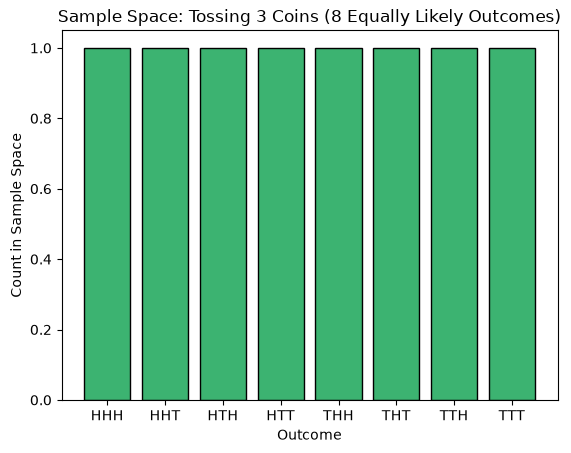

Sample Space: ['HHH', 'HHT', 'HTH', 'HTT', 'THH', 'THT', 'TTH', 'TTT']
Total outcomes |S| = 8


In [3]:
import itertools
import matplotlib.pyplot as plt

outcomes = [''.join(o) for o in itertools.product('HT', repeat=3)]
counts = [1] * len(outcomes)  # each outcome is equally likely

plt.bar(outcomes, counts, edgecolor="black", color="mediumseagreen")
plt.title("Sample Space: Tossing 3 Coins (8 Equally Likely Outcomes)")
plt.xlabel("Outcome")
plt.ylabel("Count in Sample Space")
plt.show()

print("Sample Space:", outcomes)
print("Total outcomes |S| =", len(outcomes))

### Interpretation:
All 8 outcomes of tossing 3 coins are listed and equally weighted, showing the full sample space before any event or probability is calculated.

### Advantages:
- Explicitly listing the sample space avoids missed or double-counted outcomes.
- Provides the denominator needed for classical probability calculations.

### Limitations:
- Sample spaces can become extremely large (combinatorial explosion) for complex experiments.
- Continuous sample spaces (e.g., time, temperature) have infinite outcomes and require different tools (density functions).

## 04. Independent Events

**Definition**: Two events are independent if the occurrence of one does not affect the probability of the other occurring.

**Formula**: P(A ∩ B) = P(A) × P(B)

**Real-World Example**: Flipping a coin twice — the result of the first flip has no effect on the second.

**Business Example**: The success of two unrelated ad campaigns run in different countries.

**AI/ML Example**: Naive Bayes classifiers assume features are conditionally independent given the class label.

**Numerical Example**: P(heads on flip 1 AND heads on flip 2) = 0.5 × 0.5 = 0.25.

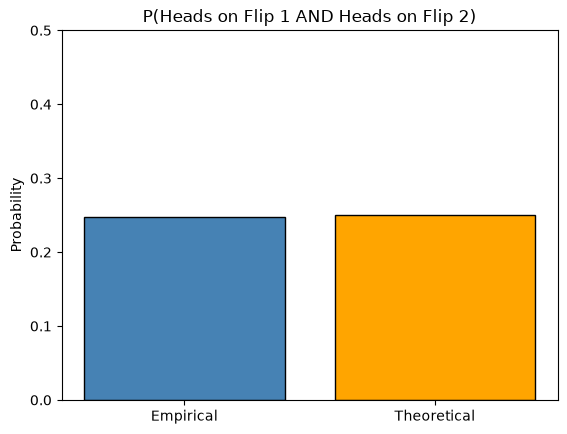

Empirical P(both heads): 0.2481
Theoretical P(both heads): 0.25


In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7)
n = 10000
flip1 = np.random.randint(0, 2, size=n)  # 1 = heads
flip2 = np.random.randint(0, 2, size=n)

both_heads_empirical = np.mean((flip1 == 1) & (flip2 == 1))
theoretical = 0.5 * 0.5

plt.bar(["Empirical", "Theoretical"], [both_heads_empirical, theoretical],
        color=["steelblue", "orange"], edgecolor="black")
plt.title("P(Heads on Flip 1 AND Heads on Flip 2)")
plt.ylabel("Probability")
plt.ylim(0, 0.5)
plt.show()

print("Empirical P(both heads):", round(both_heads_empirical, 4))
print("Theoretical P(both heads):", theoretical)

### Interpretation:
The empirical probability of getting heads on both flips closely matches the theoretical 0.25, confirming the two coin flips behave as independent events.

### Advantages:
- Independence greatly simplifies joint probability calculations (simple multiplication).
- Widely (and often reasonably) assumed in models like Naive Bayes for computational efficiency.

### Limitations:
- Real-world events are often not truly independent, and assuming independence when it doesn't hold leads to biased estimates.
- Testing for true independence in observed data can be statistically challenging.

## 05. Dependent Events

**Definition**: Two events are dependent if the occurrence of one event changes the probability of the other occurring.

**Formula**: P(A ∩ B) = P(A) × P(B | A)

**Real-World Example**: Drawing two cards from a deck without replacement — the second draw's probabilities depend on the first.

**Business Example**: The probability a customer churns given they previously filed a complaint.

**AI/ML Example**: Sequential models (e.g., time series, RNNs) explicitly model dependence between past and future states.

**Numerical Example**: P(drawing 2 aces in a row without replacement) = (4/52) × (3/51) ≈ 0.00452.

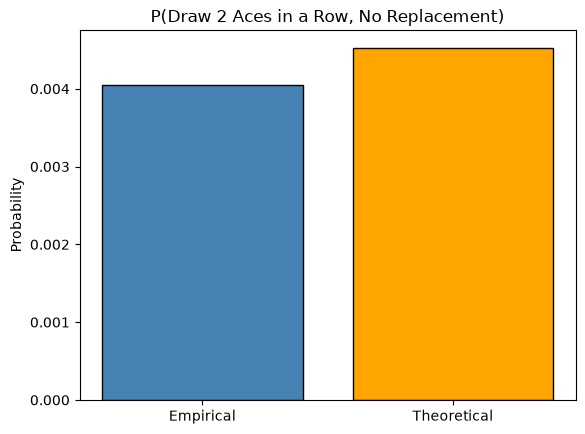

Empirical: 0.00405
Theoretical: 0.00452


In [5]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(3)
deck = ['ace']*4 + ['other']*48
trials = 20000
both_aces = 0

for _ in range(trials):
    draw = np.random.choice(deck, size=2, replace=False)
    if draw[0] == 'ace' and draw[1] == 'ace':
        both_aces += 1

empirical = both_aces / trials
theoretical = (4/52) * (3/51)

plt.bar(["Empirical", "Theoretical"], [empirical, theoretical],
        color=["steelblue", "orange"], edgecolor="black")
plt.title("P(Draw 2 Aces in a Row, No Replacement)")
plt.ylabel("Probability")
plt.show()

print("Empirical:", round(empirical, 5))
print("Theoretical:", round(theoretical, 5))

### Interpretation:
The empirical probability of drawing two aces in a row without replacement closely tracks the theoretical value, showing how the first draw changes the odds for the second.

### Advantages:
- Modeling dependence captures realistic relationships that independence assumptions would miss.
- Essential for accurate risk, forecasting, and sequential decision-making models.

### Limitations:
- Dependent probability calculations are more complex and require conditional probability.
- Mis-specifying the dependency structure can lead to compounding errors.

## 06. Conditional Probability

**Definition**: The probability of event A occurring given that event B has already occurred.

**Formula**: P(A | B) = P(A ∩ B) / P(B)

**Real-World Example**: The probability it rains given that the sky is cloudy.

**Business Example**: The probability a customer purchases given they already added an item to their cart.

**AI/ML Example**: Conditional probability underlies Bayesian models, spam filters, and recommendation systems ("given past purchases, what's the probability of buying X?").

**Numerical Example**: From a deck of cards, P(King | Face card) = 4/12 ≈ 0.333, since there are 12 face cards and 4 are Kings.

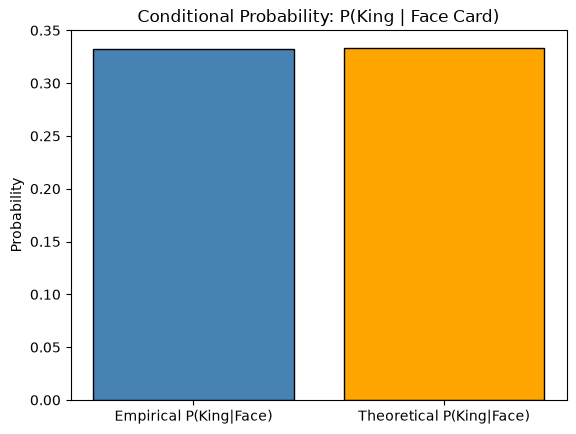

Empirical: 0.3322
Theoretical: 0.3333


In [6]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(5)
ranks = (['King']*4 + ['Queen']*4 + ['Jack']*4 + ['Other']*40)
trials = 20000
draws = np.random.choice(ranks, size=trials, replace=True)

face_cards = np.isin(draws, ['King', 'Queen', 'Jack'])
kings_given_face = np.mean(draws[face_cards] == 'King')
theoretical = 4/12

plt.bar(["Empirical P(King|Face)", "Theoretical P(King|Face)"],
        [kings_given_face, theoretical], color=["steelblue", "orange"], edgecolor="black")
plt.title("Conditional Probability: P(King | Face Card)")
plt.ylabel("Probability")
plt.show()

print("Empirical:", round(kings_given_face, 4))
print("Theoretical:", round(theoretical, 4))

### Interpretation:
Restricting attention to only face-card draws, roughly one-third turn out to be Kings, matching the theoretical conditional probability of 4/12.

### Advantages:
- Lets us update beliefs about an event using relevant, known information.
- Central to real-time decision systems (recommendations, fraud detection, diagnostics).

### Limitations:
- Requires an accurate estimate of P(B), which can be hard to obtain with sparse data.
- Easy to misinterpret or confuse P(A|B) with P(B|A) ("prosecutor's fallacy").

## 07. Bayes' Theorem

**Definition**: A rule for updating the probability of a hypothesis as new evidence becomes available, combining prior belief with the likelihood of observed evidence.

**Formula**: P(A | B) = [P(B | A) × P(A)] / P(B)

**Real-World Example**: Estimating the probability a patient has a disease given a positive test result, accounting for test accuracy and disease prevalence.

**Business Example**: Estimating the probability a transaction is fraudulent given that it was flagged by a rule-based system.

**AI/ML Example**: The Naive Bayes classifier applies Bayes' Theorem directly, combining feature likelihoods with class priors to predict labels.

**Numerical Example**: Disease prevalence 1%, test sensitivity 99%, false positive rate 5% → P(Disease | Positive) ≈ 0.166.

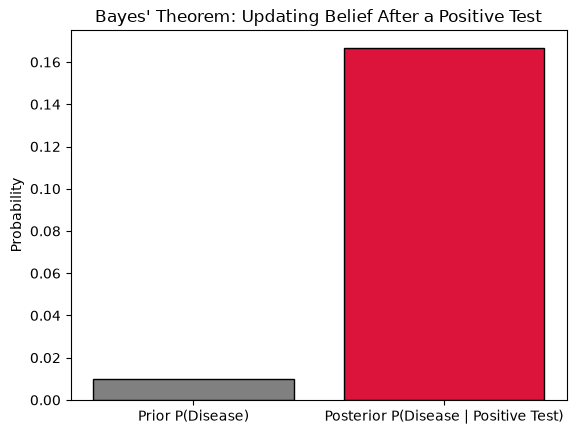

P(Disease | Positive) = 0.1667


In [7]:
import matplotlib.pyplot as plt

# Priors and likelihoods
p_disease = 0.01
p_no_disease = 1 - p_disease
p_pos_given_disease = 0.99      # sensitivity
p_pos_given_no_disease = 0.05   # false positive rate

# Bayes' Theorem
p_pos = (p_pos_given_disease * p_disease) + (p_pos_given_no_disease * p_no_disease)
p_disease_given_pos = (p_pos_given_disease * p_disease) / p_pos

plt.bar(["Prior P(Disease)", "Posterior P(Disease | Positive Test)"],
        [p_disease, p_disease_given_pos], color=["gray", "crimson"], edgecolor="black")
plt.title("Bayes' Theorem: Updating Belief After a Positive Test")
plt.ylabel("Probability")
plt.show()

print("P(Disease | Positive) =", round(p_disease_given_pos, 4))

### Interpretation:
Even with a highly accurate test, the posterior probability of actually having the disease after a positive result is much lower than intuition suggests (~16.6%), because the disease is rare — a classic illustration of base-rate effects.

### Advantages:
- Formally combines prior knowledge with new evidence for more accurate predictions.
- Powers many practical AI/ML systems (spam filters, medical diagnosis support, recommendation engines).

### Limitations:
- Highly sensitive to the accuracy of the prior probability — a wrong prior skews results significantly.
- Naive Bayes' independence assumption between features is often violated in real data.

## 08. Probability Rules

**Definition**: The foundational rules that govern how probabilities combine — the Addition Rule, Multiplication Rule, and Complement Rule.

**Formula**: P(A ∪ B) = P(A) + P(B) − P(A ∩ B) | P(A ∩ B) = P(A) × P(B|A) | P(A′) = 1 − P(A)

**Real-World Example**: The probability of drawing a heart OR a face card from a deck of cards.

**Business Example**: The probability a customer uses a promo code OR is a repeat buyer (some customers may be both).

**AI/ML Example**: Ensemble methods combine probabilities from multiple models using rules similar to the addition and multiplication rules.

**Numerical Example**: P(Heart or Face card) = 13/52 + 12/52 − 3/52 = 22/52 ≈ 0.423 (3 cards are both heart and face card).

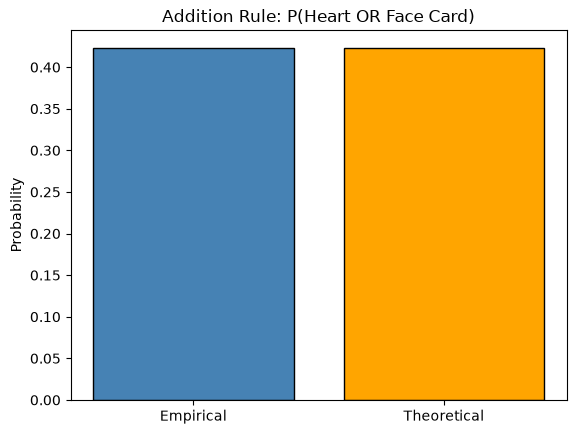

Empirical: 0.4228
Theoretical: 0.4231


In [8]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(9)
suits = ['Heart']*13 + ['Other']*39
faces = ['Face']*12 + ['NonFace']*40

trials = 20000
suit_draw = np.random.choice(suits, size=trials)
face_draw = np.random.choice(faces, size=trials)

is_heart = suit_draw == 'Heart'
is_face = face_draw == 'Face'
empirical = np.mean(is_heart | is_face)
theoretical = 13/52 + 12/52 - 3/52

plt.bar(["Empirical", "Theoretical"], [empirical, theoretical],
        color=["steelblue", "orange"], edgecolor="black")
plt.title("Addition Rule: P(Heart OR Face Card)")
plt.ylabel("Probability")
plt.show()

print("Empirical:", round(empirical, 4))
print("Theoretical:", round(theoretical, 4))

### Interpretation:
The simulated probability of drawing a heart or a face card is close to the theoretical value from the Addition Rule, which subtracts the overlap (hearts that are also face cards) to avoid double-counting.

### Advantages:
- Probability rules provide a consistent toolkit to compute probabilities for any combination of events.
- Enable exact calculations without needing to enumerate every possible outcome.

### Limitations:
- The addition rule requires correctly identifying overlaps (P(A ∩ B)); forgetting to subtract them is a common error.
- Rules assume events are well-defined; ambiguous or overlapping event definitions cause miscalculation.

## 09. Random Variables

**Definition**: A variable whose possible values are numerical outcomes of a random phenomenon. Can be discrete (countable values) or continuous (any value in a range).

**Formula**: E[X] = Σ x·P(X = x) for discrete random variables.

**Real-World Example**: The number of heads obtained in 10 coin flips (discrete random variable).

**Business Example**: The number of customer support calls received per day.

**AI/ML Example**: Model outputs (predicted class probabilities) and features are treated as random variables when reasoning about uncertainty.

**Numerical Example**: X = sum of two dice rolls; X can take values from 2 to 12, each with its own probability.

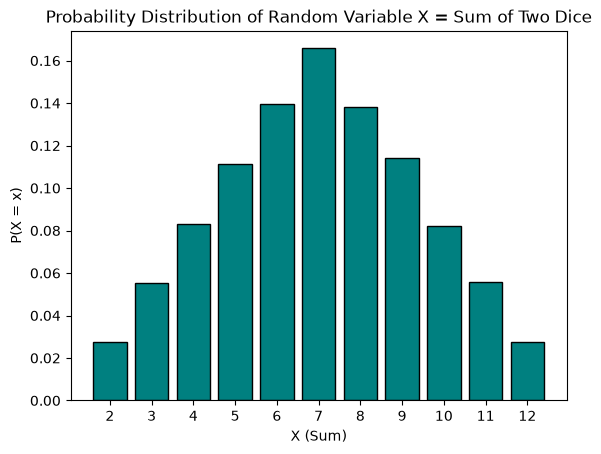

In [9]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(11)
die1 = np.random.randint(1, 7, size=100000)
die2 = np.random.randint(1, 7, size=100000)
X = die1 + die2

values, counts = np.unique(X, return_counts=True)
probs = counts / len(X)

plt.bar(values, probs, edgecolor="black", color="teal")
plt.title("Probability Distribution of Random Variable X = Sum of Two Dice")
plt.xlabel("X (Sum)")
plt.ylabel("P(X = x)")
plt.xticks(values)
plt.show()

### Interpretation:
The distribution of X forms a triangular shape peaking at 7, showing that mid-range sums are far more likely than extremes (2 or 12), since there are more combinations of dice that produce them.

### Advantages:
- Random variables let us apply mathematical tools (expectation, variance) to random outcomes.
- Bridge the gap between raw probability and statistics used in modeling.

### Limitations:
- Choosing the wrong type (discrete vs. continuous) or distribution can misrepresent the underlying process.
- Real-world random variables may not follow any simple, well-known distribution.

## 10. Expected Value

**Definition**: The long-run average value of a random variable over many repetitions of an experiment, weighted by probability.

**Formula**: E[X] = Σ x · P(X = x)

**Real-World Example**: The expected winnings from playing a lottery, averaged over many draws.

**Business Example**: The expected revenue from a marketing campaign, given the probabilities and payoffs of different customer responses.

**AI/ML Example**: Reinforcement learning agents aim to maximize expected cumulative reward; loss functions are often expected values over the data distribution.

**Numerical Example**: A dice game pays ₹10 for rolling a 6 and costs ₹2 otherwise. E[X] = (1/6)(10) + (5/6)(−2) = ₹0.

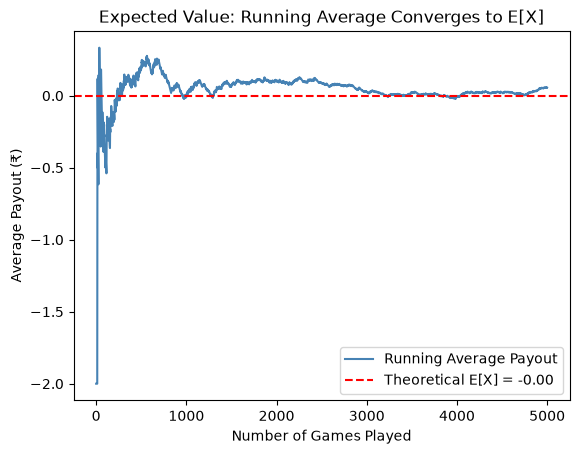

In [10]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(21)
n_games = 5000
rolls = np.random.randint(1, 7, size=n_games)
payouts = np.where(rolls == 6, 10, -2)

running_average = np.cumsum(payouts) / np.arange(1, n_games + 1)
theoretical_ev = (1/6)*10 + (5/6)*(-2)

plt.plot(running_average, color="steelblue", label="Running Average Payout")
plt.axhline(theoretical_ev, color="red", linestyle="--", label=f"Theoretical E[X] = {theoretical_ev:.2f}")
plt.title("Expected Value: Running Average Converges to E[X]")
plt.xlabel("Number of Games Played")
plt.ylabel("Average Payout (₹)")
plt.legend()
plt.show()

### Interpretation:
As more games are played, the running average payout converges to the theoretical expected value (₹0), showing that expected value predicts long-run average outcomes, not any single game's result.

### Advantages:
- Provides a single summary number to compare risky options or decisions.
- Foundational to decision theory, finance, insurance pricing, and reinforcement learning.

### Limitations:
- A fair expected value can still hide high variance/risk in individual outcomes.
- Doesn't capture the shape of the distribution — two very different games can share the same expected value.

## Interview Questions and Answers

**1. What is the difference between an event and a sample space?**
The sample space is the set of *all* possible outcomes of an experiment, while an event is any subset of that sample space (one or more specific outcomes of interest).

**2. How do you distinguish independent events from dependent events?**
Events are independent if P(A|B) = P(A), i.e., knowing B occurred doesn't change the probability of A. If P(A|B) ≠ P(A), the events are dependent.

**3. What is conditional probability, and how is it calculated?**
It's the probability of an event given that another event has already occurred, calculated as P(A|B) = P(A∩B) / P(B).

**4. State Bayes' Theorem and explain its practical use.**
P(A|B) = [P(B|A)·P(A)] / P(B). It's used to update the probability of a hypothesis (e.g., disease presence) after observing new evidence (e.g., a test result), combining prior belief with likelihood.

**5. Why is the Addition Rule P(A∪B) = P(A) + P(B) − P(A∩B) and not just P(A) + P(B)?**
Simply adding P(A) and P(B) double-counts outcomes that belong to both events; subtracting P(A∩B) corrects for that overlap.

**6. What's the difference between a random variable and a probability distribution?**
A random variable is the numeric outcome of a random process (e.g., sum of two dice); its probability distribution describes how likely each possible value of that variable is.

**7. What does Expected Value represent, and what does it NOT tell you?**
It represents the long-run average outcome over many repetitions. It does not tell you about the variability, risk, or shape of the distribution — two options with the same expected value can have very different risk profiles.

**8. Why does Naive Bayes assume feature independence, and what's the risk of that assumption?**
It assumes independence to simplify the joint probability calculation into a product of individual likelihoods, making the model fast and scalable. The risk is that correlated features can bias predictions since their combined evidence gets "double-counted."

## Self Reflection

Working through probability concepts reinforced that uncertainty isn't something to avoid in data work — it's something to *measure and reason about* systematically. Key takeaways:
- **Sample space and events** give the vocabulary to precisely define "what could happen" and "what we care about."
- **Independent vs. dependent events** shapes how joint probabilities must be calculated — assuming independence incorrectly is a common source of modeling errors.
- **Conditional probability and Bayes' Theorem** showed how prior beliefs should be updated with new evidence, and how base rates can make intuitive answers misleading (e.g., the disease-testing example).
- **Probability rules** (addition, multiplication, complement) are the building blocks for combining any events, no matter how complex.
- **Random variables and Expected Value** connect probability to real decision-making — from dice games to business forecasting to reinforcement learning rewards — by summarizing uncertain outcomes into actionable numbers.

Overall, probability is the language that lets statistics and machine learning talk about what's *likely*, not just what's *observed* — a foundation I'll keep leaning on for distributions, hypothesis testing, and predictive modeling.